In this notebook we shall learn the antiderivative (integral) operator, $\mathcal{G}$ defined as :

$$ u(x) = \mathcal{G}[a](x) = \int_0^x a(s) ds $$

using a DeepONet architecture.

The Branch Net shall recieve the discretized input functions $a_i(s_j)$, while the Trunk Net shall take in the query points $x_i$.

## 1. Generating Random Input Functions.

In this notebook, we shall confine to taking the input functions, $a(x)$ of the following form :

$$ a(x) = \sum_{n=1}^N \left[ A_n\sin(n\pi x) + B_n\cos(n\pi x) \right] $$

where $ A_n $ and $ B_n $ are random coefficients sampled from $\mathcal{U}(-1,1)$.

The exact antiderivatives are given by :

$$ u(x) = \sum_{n=1}^N \left[ \dfrac{A_n}{n\pi}(1 - \cos(n\pi x)) + \dfrac{B_n}{n\pi}\sin(n\pi x) \right] $$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [2]:
# constants
pi = torch.pi

In [3]:
# constructing input functions and the corresponding outputs
def input_output_funcs(N_func, sensor_points, query_points, coeff, N_sensor, N_query, N_coeff):
    # dim of sensor points : N_sensor
    # dim of coeff : N_func x 2N_coeff
    # dim of 'a' needed : N_func x N_sensor
    # dim of 'u' needed : N_func x N_query

    A,B = coeff[:,:N_coeff], coeff[:,N_coeff:]
    a = torch.zeros(N_func,N_sensor)
    u = torch.zeros(N_func,N_query)
    for n in range(0,N_coeff):
        arg_a = (n+1)*pi*sensor_points
        arg_u = (n+1)*pi*query_points
        a += torch.outer(A[:,n], torch.sin(arg_a)) + torch.outer(B[:,n], torch.cos(arg_a))
        u += torch.outer(A[:,n], (1 - torch.cos(arg_u))) / ((n+1)*pi) + torch.outer(B[:,n], torch.sin(arg_u)) / ((n+1)*pi)
    return a, u

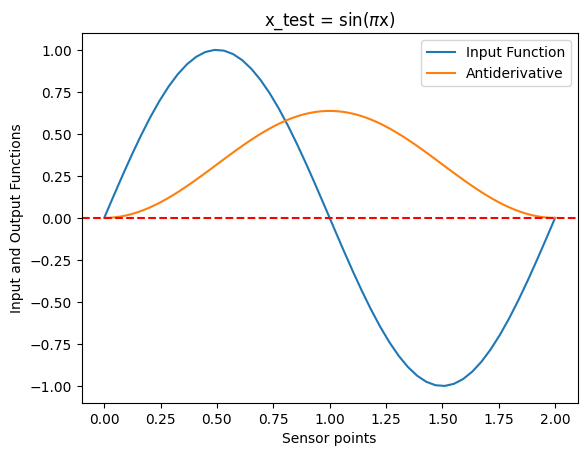

In [4]:
# testing the input output functions
# test 1
coeff_test = torch.tensor([[1.0,0.0]])
N_coeff_test = int(coeff_test.size()[1]/2)
N_sensor_test = 50
N_query_test = 80
sensor_points_test = torch.linspace(0.0,2.0,N_sensor_test,requires_grad=False)
query_points_test = torch.linspace(0.0,2.0,N_query_test,requires_grad=False)
a_test, u_test = input_output_funcs(1,sensor_points_test,query_points_test,coeff_test,N_sensor_test,N_query_test, N_coeff_test)
# print(a_test.shape, u_test.shape)

plt.plot(sensor_points_test.detach(),a_test.detach().flatten(),label = 'Input Function')
plt.plot(query_points_test.detach(),u_test.detach().flatten(),label = 'Antiderivative')
plt.axhline(0,c='red',ls = '--')
plt.legend()
plt.title("x_test = sin($\\pi$x)")
plt.xlabel('Sensor points')
plt.ylabel('Input and Output Functions')
plt.show()

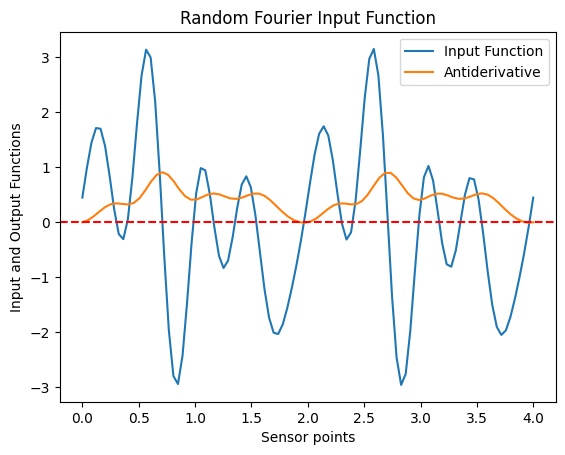

In [5]:
# testing the input output functions
# test 2
N_coeff_test = 5
N_sensor_test = 100
N_query_test = 80
coeff_test = 2 * torch.rand(1,2*N_coeff_test) - 1
sensor_points_test = torch.linspace(0.0,4.0,N_sensor_test,requires_grad=False)
query_points_test = torch.linspace(0.0,4.0,N_query_test,requires_grad=False)
a_test, u_test = input_output_funcs(1,sensor_points_test,query_points_test,coeff_test,N_sensor_test,N_query_test, N_coeff_test)
# print(a_test.shape, u_test.shape)

plt.plot(sensor_points_test.detach(),a_test.detach().flatten(),label = 'Input Function')
plt.plot(query_points_test.detach(),u_test.detach().flatten(),label = 'Antiderivative')
plt.axhline(0,c='red',ls = '--')
plt.legend()
plt.title("Random Fourier Input Function")
plt.xlabel('Sensor points')
plt.ylabel('Input and Output Functions')
plt.show()

# 2. Building the DeepONet Architecture.

In [6]:
class DeepONet(nn.Module):
    def __init__(self, N_sensor, embed_dim):
        super().__init__()

        # Branch network
        self.branch = nn.Sequential(
            nn.Linear(N_sensor, 64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,embed_dim)
        )

        # Trunk network
        self.trunk = nn.Sequential(
            nn.Linear(1,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64, embed_dim)
        )

        # Bias term
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, trunk_input):
        b = self.branch(branch_input)
        t = self.trunk(trunk_input)
        return b @ t.T + self.bias

# 3. Preparing Training and Testing Functions

### 3.1. Dimension of branch input.

A single function is specified by 50 sensor points. Thus a single function looks like $ [a_1, a_2, ..., a_{50}] $.

Next, there are 100 such (most probably distinct) functions : $ [[a_1^1,a_2^1,...,a_{50}^1],[a_1^2,a_2^2,...,a_{50}^2],...,[a_1^{100},a_2^{100},...,a_{50}^{100}]] $. This matrix has dimension :
$$ 100 \times 50 $$

### 3.2. Dimension of trunk input.

A single input function has corresponding 80 query locations : $ [x_1, x_2, ..., x_{80}]^T $. Thus, the dimension of trunk input is :

$$ 80 \times 1 $$

### 3.3. Dimension of the DeepONet output.

The branch net yields an output of dimension : $ 100 \times 32 $.

The trunk net also yields an output of dimension : $ 80 \times 32 $.

The DeepONet prediction is a matrix of size : $ (100,32)@(80,32)^T = 100\times80 $.

### 3.4. Dimension of the target output.

The output of a single input function is the antiderivative function evaluated at 80 query locations : $ [u_1, u_2, ...,u_{80}] $

Since, there exist 100 such training functions. We have $ [[u_1^1, u_2^1, ...,u_{80}^1], [u_1^2, u_2^2, ...,u_{80}^2], ..., [u_1^{100}, u_2^{100}, ...,u_{80}^{100}]] $. The dimension of this matrix is :

$$ 100 \times 80 $$

In [7]:
N_coeff = 10                        # no. of fourier modes used for creating input functions
N_train = 1000                      # no. of training functions
N_test = 200                        # no. of testing functions
N_sensor = 150                      # no. of sensor points per function
N_query = 80                        # no. of query loactions for each function
embed_dim = 64                      # dimension of the embedding space used

In [8]:
sensor_points = torch.linspace(0.0,1.0,N_sensor)
query_points = torch.linspace(0.0,1.0,N_query)
train_coeff = 2 * torch.rand([N_train , 2*N_coeff]) - 1
test_coeff = 2 * torch.rand([N_test , 2*N_coeff]) - 1
train_a, train_u = input_output_funcs(N_train, sensor_points, query_points, train_coeff, N_sensor, N_query, N_coeff)
test_a, test_u = input_output_funcs(N_test, sensor_points, query_points, test_coeff, N_sensor, N_query, N_coeff)

print("Shape of the Data :\n")
print(f"Training Branch Input : {train_a.shape}")
print(f"Training Target Output : {train_u.shape}")
print(f"Testing Branch Input : {test_a.shape}")
print(f"Testing Target Output : {test_u.shape}")
print(f"Query Input / Trunk Input : {query_points.reshape(-1,1).shape}")

Shape of the Data :

Training Branch Input : torch.Size([1000, 150])
Training Target Output : torch.Size([1000, 80])
Testing Branch Input : torch.Size([200, 150])
Testing Target Output : torch.Size([200, 80])
Query Input / Trunk Input : torch.Size([80, 1])


# 3. Building the Loss Function.

In [9]:
def Loss(model, branch_input, trunk_input, u_true):
    # If we consider the training functions above, then :
    # branch_input : train_a with shape 100,50
    # trunk_input : query_points.reshape(-1,1) with shape 80,1

    u_pred = model(branch_input, trunk_input)
    loss = torch.mean((u_pred - u_true)**2)
    return loss, u_pred

In [10]:
# Defining the optimizer
model = DeepONet(N_sensor, embed_dim)
# Adam Optimizer
adam_optim = torch.optim.Adam(model.parameters(), lr = 0.002)
# LBFGS Optimizer
lbfgs_optim = torch.optim.LBFGS(model.parameters(), lr = 1.0, max_iter=20000, max_eval=20000, tolerance_grad=10**-10, tolerance_change=10**-14, line_search_fn="strong_wolfe")

In [11]:
# training the model
# using Adam optimizer
N_epochs = 10000
adam_loss_arr = []
print("Training using using Adam optimizer started ...")
for epoch in range(N_epochs):
    adam_optim.zero_grad()
    loss, _ = Loss(model, train_a, query_points.reshape(-1,1), train_u)
    adam_loss_arr.append(loss.item())
    loss.backward()
    adam_optim.step()
print("Training using using Adam optimizer finished.\n")

# using lbfgs optimizer
lbfgs_loss_arr = []
print("Training using using LBFGS optimizer started ...")
def closure():
    lbfgs_optim.zero_grad()
    loss, _ = Loss(model, train_a, query_points.reshape(-1,1), train_u)
    lbfgs_loss_arr.append(loss.item())
    loss.backward()
    return loss

lbfgs_optim.step(closure)
print("Training using using LBFGS optimizer finished.")

Training using using Adam optimizer started ...
Training using using Adam optimizer finished.

Training using using LBFGS optimizer started ...
Training using using LBFGS optimizer finished.


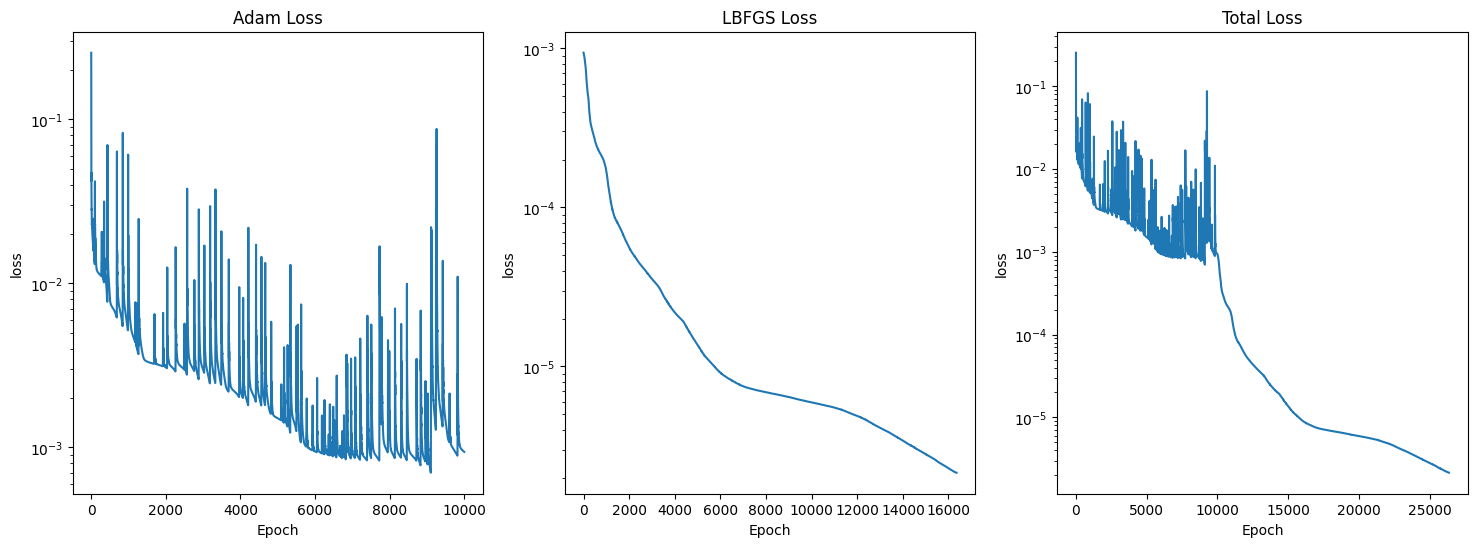

In [12]:
# visualing the loss
plt.figure(figsize = (18,6))

plt.subplot(1,3,1)
plt.semilogy(adam_loss_arr)
plt.title("Adam Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.subplot(1,3,2)
plt.semilogy(lbfgs_loss_arr)
plt.title("LBFGS Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.subplot(1,3,3)
plt.semilogy(adam_loss_arr + lbfgs_loss_arr)
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.show()

# 4. Testing the Model.

In [13]:
# MSE
with torch.no_grad():
    u_test_pred = model(test_a, query_points.reshape(-1,1))
    u_train_pred = model(train_a, query_points.reshape(-1,1))

train_mse = torch.mean((train_u - u_train_pred)**2)
test_mse = torch.mean((test_u - u_test_pred)**2)
print(f"Test MSE: {test_mse.item():.6e}")
print(f"Train MSE: {train_mse.item():.6e}")

Test MSE: 2.729551e-06
Train MSE: 2.144902e-06


In [14]:
# Relative L-square error
relative_errors = (torch.linalg.vector_norm( u_test_pred - test_u, dim=1 ) / torch.linalg.vector_norm( test_u, dim=1 ))
mean_relative_error = relative_errors.mean()
print("Mean relative L2 error:",mean_relative_error.item())

Mean relative L2 error: 0.0066849649883806705


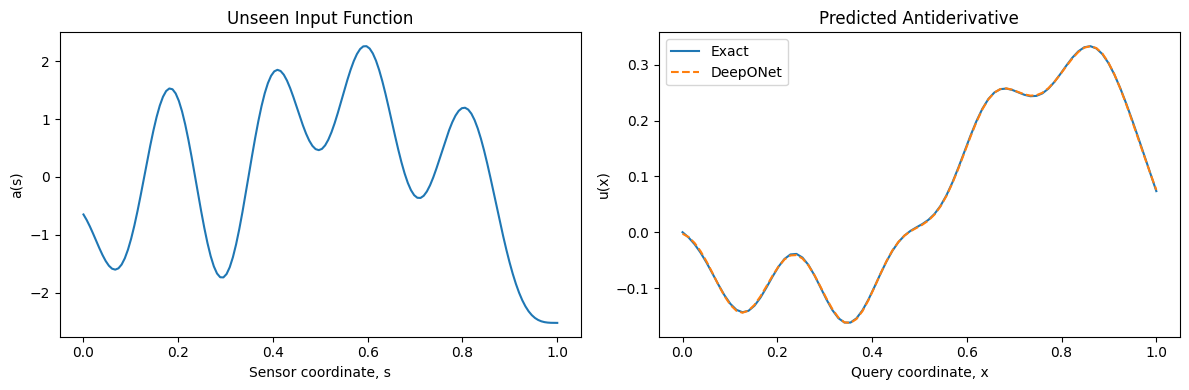

In [15]:
test_index = 0
fig, axes = plt.subplots(1,2,figsize=(12, 4))

axes[0].plot(sensor_points,test_a[test_index])
axes[0].set_xlabel("Sensor coordinate, s")
axes[0].set_ylabel("a(s)")
axes[0].set_title("Unseen Input Function")

axes[1].plot(query_points,test_u[test_index],label="Exact")
axes[1].plot(query_points,u_test_pred[test_index],linestyle="--",label="DeepONet")
axes[1].set_xlabel("Query coordinate, x")
axes[1].set_ylabel("u(x)")
axes[1].set_title("Predicted Antiderivative")
axes[1].legend()

plt.tight_layout()
plt.show()

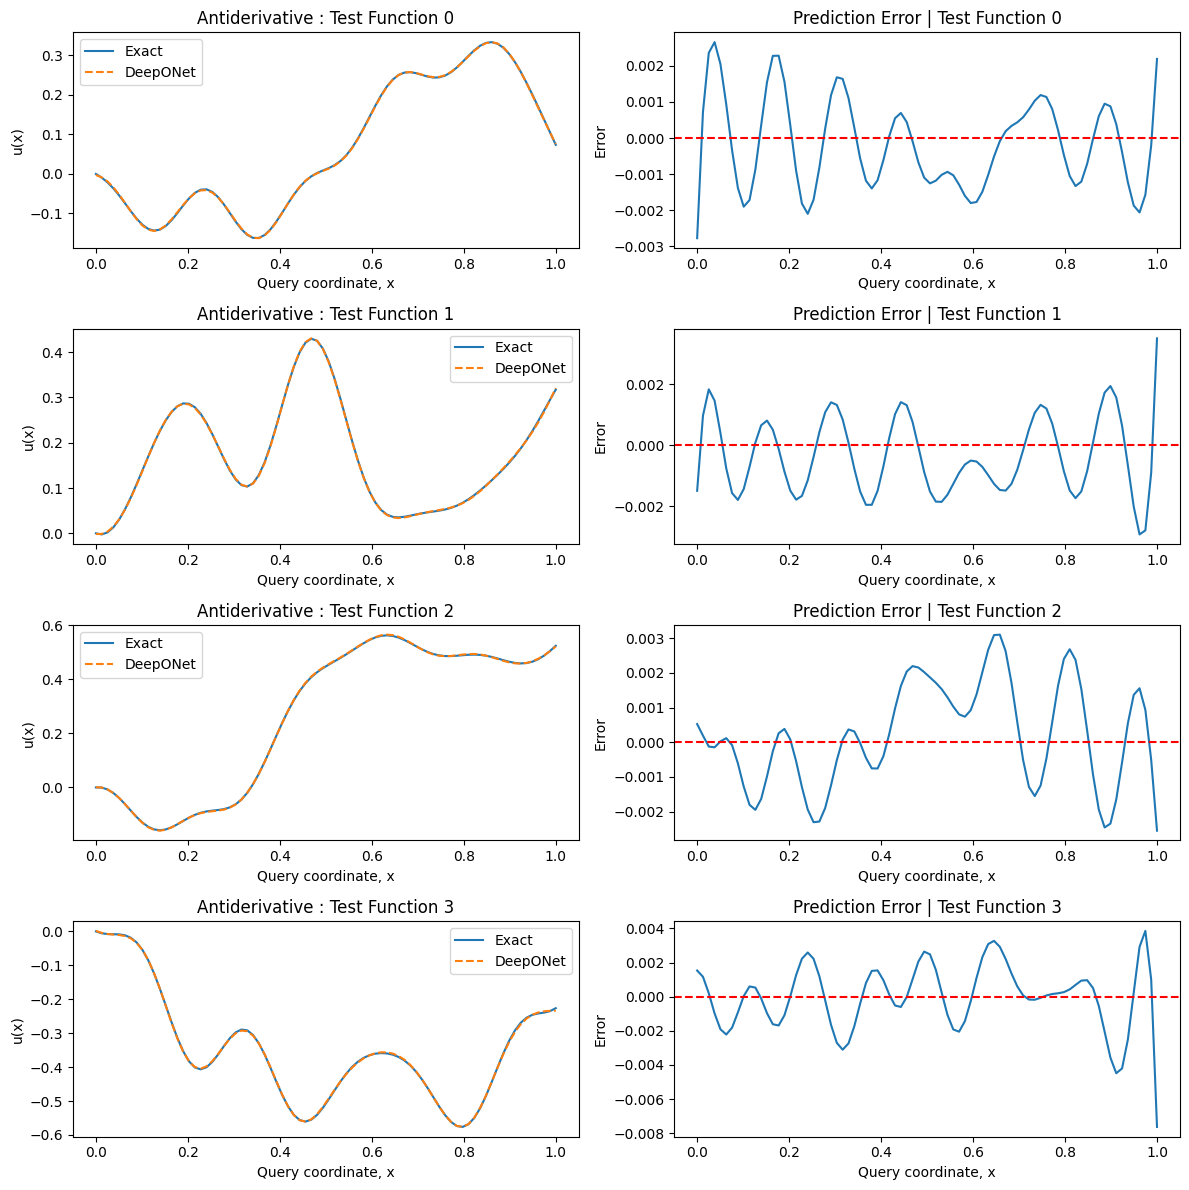

In [16]:
test_indices = [0, 1, 2, 3]

fig, axes = plt.subplots(len(test_indices),2,figsize=(12, 3 * len(test_indices)))

for row, test_index in enumerate(test_indices):

    # Exact vs Predicted
    axes[row, 0].plot(query_points,test_u[test_index],label="Exact")
    axes[row, 0].plot(query_points,u_test_pred[test_index],linestyle="--",label="DeepONet")
    axes[row, 0].set_xlabel("Query coordinate, x")
    axes[row, 0].set_ylabel("u(x)")
    axes[row, 0].set_title(f"Antiderivative : Test Function {test_index}")
    axes[row, 0].legend()

    # Prediction Error
    error = (u_test_pred[test_index] - test_u[test_index])
    axes[row, 1].plot(query_points,error)
    axes[row, 1].set_xlabel("Query coordinate, x")
    axes[row, 1].set_ylabel("Error")
    axes[row, 1].set_title(f"Prediction Error | Test Function {test_index}")
    axes[row, 1].axhline(0,ls = '--', c='red')

plt.tight_layout()
plt.show()